<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/S7_Internship_d10_GAN%26Diffusion_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(),lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(),lr=0.0002)

epochs = 20

for epoch in range(epochs):

    for imgs,_ in loader:

        real_imgs = imgs.view(-1,784).to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train D
        outputs = D(real_imgs)
        d_real_loss = criterion(outputs,real_labels)

        z = torch.randn(batch_size,100).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs.detach())
        d_fake_loss = criterion(outputs,fake_labels)

        d_loss = d_real_loss + d_fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train G
        outputs = D(fake_imgs)

        g_loss = criterion(outputs,real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] D:{d_loss.item():.4f} G:{g_loss.item():.4f}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 275kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.3MB/s]


Epoch [1/20] D:0.0633 G:4.2536
Epoch [2/20] D:0.0178 G:6.1763
Epoch [3/20] D:0.0312 G:7.5288
Epoch [4/20] D:0.0729 G:5.5945
Epoch [5/20] D:0.3072 G:8.2714
Epoch [6/20] D:0.0955 G:4.7050
Epoch [7/20] D:0.1312 G:4.0826
Epoch [8/20] D:0.3639 G:4.1633
Epoch [9/20] D:0.2573 G:3.8156
Epoch [10/20] D:0.3371 G:3.0970
Epoch [11/20] D:0.2768 G:5.0039
Epoch [12/20] D:0.1557 G:3.6023
Epoch [13/20] D:0.7450 G:2.3359
Epoch [14/20] D:0.5839 G:4.4858
Epoch [15/20] D:0.6053 G:2.9223
Epoch [16/20] D:0.3102 G:4.0150
Epoch [17/20] D:0.2601 G:2.8056
Epoch [18/20] D:0.6748 G:2.7051
Epoch [19/20] D:0.7040 G:2.7778
Epoch [20/20] D:0.6005 G:2.9913


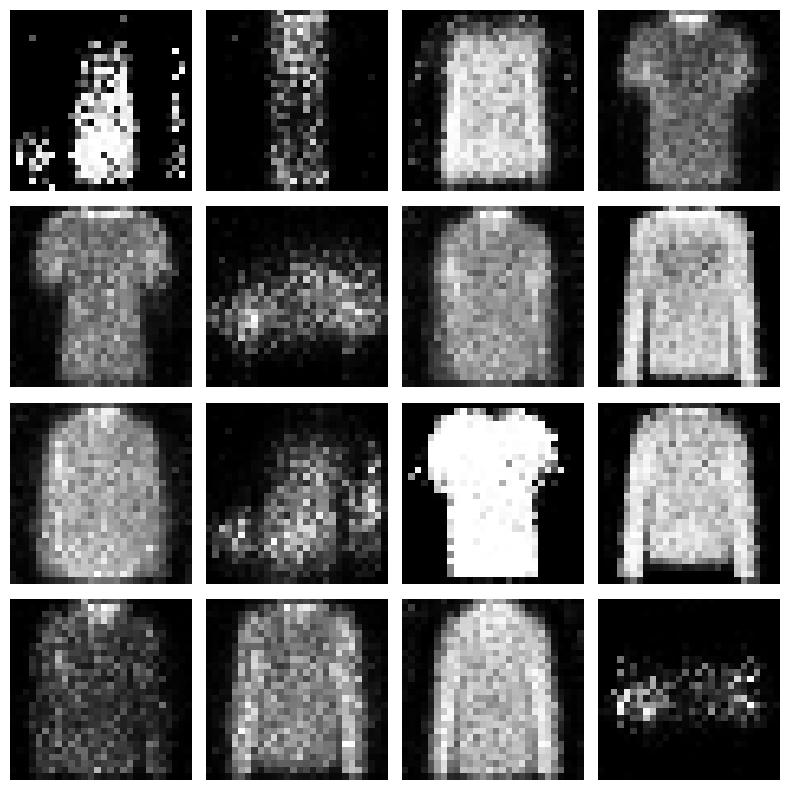

In [5]:
import matplotlib.pyplot as plt
import torch

G.eval()

with torch.no_grad():
  z = torch.randn(16, 100).to(device)
  generated_images = G(z)

generated_images = generated_images.cpu().view(-1, 28, 28)

fig, axes = plt.subplots(4, 4, figsize = (8,8))

for i, ax in enumerate(axes.flat):
  ax.imshow(generated_images[i], cmap = 'gray')
  ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
for i, ax in enumerate(axes.flat):
  ax.imshow(generated_images[i], cmap = 'gray')
  ax.axis('off')

fig.suptitle("GAN Generated Fashion-MNIST Images")
plt.show()

In [8]:
from torchvision.utils import save_image

generated_images = generated_images.unsqueeze(1)

save_image(
    generated_images,
    "generated_images.png",
    nrow=4,
    normalize=True
)

DIFFUSION MODELS

In [10]:
!pip install diffusers transformers accelerate torch torchvision matplotlib tqdm

In [12]:
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from diffusers import UNet2DModel
from diffusers import DDPMScheduler

from torchvision import datasets,transforms
from torch.utils.data import DataLoader

from diffusers import UNet2DModel
from diffusers import DDPMScheduler
from tqdm.auto import tqdm


In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Running on:", device)

Running on: cpu


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset Loaded")

Dataset Loaded


In [15]:
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,

    layers_per_block=1,

    block_out_channels=(32, 64),

    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D"
    ),

    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D"
    )
).to(device)

print("Model Created")

Model Created


In [16]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps = 50
)

In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 1e-4
)